In [ ]:
import os
import operator
from typing import Literal, TypedDict, Annotated
from dotenv import load_dotenv

from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

# 🔹 GEMINI IMPORT
from langchain_google_genai import ChatGoogleGenerativeAI

# Load env (Ensure GOOGLE_API_KEY is set in your .env file)
load_dotenv()

# 🔹 INITIALIZE GEMINI
# gemini-1.5-flash is fast and great for ReAct loops. 
# Use gemini-1.5-pro for complex reasoning.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

print(f"✅ LLM initialized: {llm.model}")

✅ LLM initialized: gemini-2.5-flash


In [13]:
from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun()

@tool
def calculator(expression: str) -> str:
    """
    Calculate mathematical expressions.
    
    Args:
        expression: Math expression like "2 + 2" or "15 * 37"
    """
    try:
        # ⚠️ Safety warning: eval is dangerous in production, okay for learning
        result = eval(expression, {"__builtins__": {}}, {})
        return str(result)
    except Exception as e:
        return f"Error: {str(e)}"


tools = [calculator, search_tool] # Update your tool list
print("✅ Tools created")

✅ Tools created


In [14]:
llm_with_tools = llm.bind_tools(tools)

# Define the assistant node
def assistant_node(state: MessagesState) -> dict:
    ## Get the conversation history
    messages = state["messages"]
    
    # Invoke Gemini
    response = llm_with_tools.invoke(messages)
    #Return the response to append to state
    
    return {"messages": [response]}

    # 3. Define the Conditional Edge Logic
    
def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    last_message = state["messages"][-1]
    
    # If Gemini wants to call a tool, route to the "tools" node
    
    if last_message.tool_calls:
        return "tools"
    # Otherwise, stop
    return "__end__"

# 4. Build the Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("assistant", assistant_node)
builder.add_node("tools", ToolNode(tools)) # ToolNode automatically executes tool calls

# Add edges
builder.add_edge(START, "assistant")

builder.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "tools": "tools", 
        "__end__": END
    }
)

builder.add_edge("tools", "assistant") # Loop back to assistant after tool use 

# Compile 

agent_manual = builder.compile(checkpointer=MemorySaver())

print("✅ Agent graph compiled")

✅ Agent graph compiled


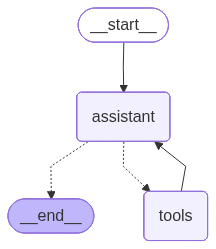

In [4]:
# Visualize the graph

try:
    from IPython.display import Image, display
    display(Image(agent_manual.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization skipped (requires dependencies)")

In [15]:
def test_agent(agent, query: str, thread_id: str = "test_1"):
    print(f"\n{"=" * 50}")
    print(f"User: {query}")
    print(f"{'=' * 50}\n")
    
    # Run the agent
    # We pass a thread_id so the memory checkpointer works
    
    result = agent.invoke(
        {"messages": [HumanMessage(content=query)]},
        config={"configurable": {"thread_id": thread_id}}
    )
    
    # Print the "Thoughts" and "Actions"
    for message in result["messages"]:
        if isinstance(message, AIMessage):
            # If the LLM has content (reasoning)
            
            if message.content:
                print(f"Assistant Thought: {message.content}")
                
            # If the LLM is calling a tool
            if message.tool_calls:
                print(f"Calling Tool: {message.tool_calls[0]['name']}")
                
        elif isinstance(message, ToolMessage):
            # The result from the tool
            print(f"Tool Result: {message.content}")
            
    print(f"\n Final Answer: {result['messages'][-1].content}")

In [16]:
test_agent(
    agent_manual,
    "What is ReAct, then tell me what 5 plus 5 is."
)


User: What is ReAct, then tell me what 5 plus 5 is.

Calling Tool: duckduckgo_search
Tool Result: Let’s say it’s your job to teach React ! What a fun challenge, there’s quite a bit of complexity to unfold, and at the same time React is a game-changer and excellent to learn. Is React a Templating Language? Is React Similar to Web Components? What Is the Difference Between the Virtual DOM and a Shadow DOM?How Can React Be Used with Other... Styling React Components. 0/2. React Tutorial Beginners For Skills Building Carrera. What Is React ( React js) & Why Is It So Popular? What is React . …more. What Is React And Why You Need To Know It.
Calling Tool: calculator
Tool Result: 10
Assistant Thought: [{'type': 'text', 'text': 'ReAct (React.js) is a popular JavaScript library for building user interfaces. 5 plus 5 is 10.', 'extras': {'signature': 'Cq0CAXLI2nz6Vbv+802S1bFeL2geFxzHBzu95vBF4ygDb5X0UDwfzJFDi9Qi5ryNUjBWSqyykEDNZ0fcw2QLoykR0nKLNmCBwuJQkXd9EMA8pMnZLFhP04hQgyfigQhaYiOW0XLtFjMu4hhHW6

In [17]:
from typing import List, TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI

import operator

class PlanExecuteState(TypedDict):
    input: str # User's original query
    plan: List[str] # The steps to follow
    past_steps: Annotated[List[tuple], operator.add] # (Step, Result) pairs
    response: str # Final answer

In [18]:

from pydantic import BaseModel, Field

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)
# 1. Define the structure for the plan 
class Plan(BaseModel):
    """Plan to follow in future"""
    steps: List[str] = Field( description= "different steps to follow, should be in sorted order")
# 2. Define the Planner Logic
def planner_node(state: PlanExecuteState):
    """We ask Gemini to output structured data matching the 'Plan' class"""
    planner = llm.with_structured_output(Plan)
    
    plan = planner.invoke(
        [SystemMessage(content= "You are a planner. Generate a step-by-step plan for the user's task."),
         HumanMessage(content = state["input"])
         ]
    )
    
    # Return the plan to the state
    return {"plan": plan.steps}

In [19]:
# We reuse the tools you already defined
import time

def executor_node(state: PlanExecuteState):
    # Get the plan 
    plan = state["plan"]
    if not plan:
        return {} # Safety check
    # Get the next step (first item in the plan)
    current_step = plan[0]
    
    # ⚠️ CRITICAL: Wait 10 seconds to respect the 15 RPM limit
    print("💤 Cooling down for API quota...")
    time.sleep(10)
    print(f"Executing step: {current_step}")
    
    # 2. Delegate to REACT AGENT
    # We use 'agent_manual' because it already knows how to use Calculator and Search!
    # We give it a unique thread_id so it doesn't get confused with previous conversations.
   
    worker_result = agent_manual.invoke(
        {"messages": [HumanMessage(content=current_step)]},
        config={"configurable": {"thread_id": "worker_agent"}}
    )
    
    # 3. Extract the result
    # The last message from the agent is its final answer
    
    step_response = worker_result["messages"][-1].content
    
    return {
        "past_steps": [(current_step, step_response)], # Save result
        "plan": plan[1:] # Remove the executed step
    }

In [20]:
from langgraph.graph import StateGraph, START, END

# Logic to check if we are done

def should_end(state: PlanExecuteState):
    if len(state["plan"]) > 0:
        return "executor" # Still have steps? Keep executing.
    return "response" # No steps? Go to final response.

# Final response Node
def response_node(state: PlanExecuteState):
    # Ask Gemini to summarize all past steps into a final answer
    context = "\n".join([f"Step: {s}\nResult: {r}" for s, r in state["past_steps"]])
    response = llm.invoke(f"Based on these results, answer the user:\n{context}")
    return {"response": response.content}
# --- BUILD GRAPH ---

workflow = StateGraph(PlanExecuteState)

workflow.add_node("planner", planner_node)
workflow.add_node("executor", executor_node)
workflow.add_node("response", response_node)

# Add Edges
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "executor")

# Conditional Edge: Loop or finish
workflow.add_conditional_edges(
    "executor",
    should_end,
    {
        "executor": "executor",
        "response": "response"
    }
)

workflow.add_edge("response", END)

# Compile

plan_execute_agent = workflow.compile()
print("Plan-Execute Agent Created")


Plan-Execute Agent Created


In [24]:
query = "What is the current world population, then calculate what 5% of that is."
result = plan_execute_agent.invoke({"input": query})
print(f"Final Answer: {result["response"]}")

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 5.314635705s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi

In [28]:
# Reflector pattern implementation

from typing import List, TypedDict
from langgraph.graph import StateGraph, START, END

class ReflectionState(TypedDict):
    messages: List[str] 
    draft: str
    critique: str
    revision_number: int

In [29]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize Gemini
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

# --- Node 1: The Generator (Writer) ---
def generator_node(state: ReflectionState):
    draft = state.get("draft", "")
    critique = state.get("critique", "")
    revision_number = state.get("revision_number", 0)
    
    # Prompt logic: Is this a first draft or a revision?
    if not critique:
        # First run: Just write it
        prompt = "You are a professional writer. Write a high-quality draft based on the user's request."
        user_msg = HumanMessage(content=state['messages'][0].content)
    else:
        # Revision run: Fix mistakes
        prompt = "You are a professional writer. Rewrite your previous draft to address the critique."
        user_msg = HumanMessage(content=f"Original Draft:\n{draft}\n\nCritique:\n{critique}\n\nWrite the new version:")
    
    response = llm.invoke([SystemMessage(content=prompt), user_msg])
    
    return {
        "draft": response.content, 
        "revision_number": revision_number + 1
    }

# --- Node 2: The Reflector (Critic) ---
def reflector_node(state: ReflectionState):
    draft = state["draft"]
    
    prompt = """You are a harsh critic. 
    Read the draft and provide specific recommendations for improvement.
    Focus on style, clarity, and following constraints.
    Do NOT rewrite the text. Just list the problems."""
    
    response = llm.invoke([
        SystemMessage(content=prompt), 
        HumanMessage(content=draft)
    ])
    
    return {"critique": response.content}

In [30]:
# Logic to stop the loop
def should_continue(state: ReflectionState):
    # Stop after 2 revisions to save time/API quota
    if state["revision_number"] > 2:
        return END
    return "reflector"

builder = StateGraph(ReflectionState)

builder.add_node("generator", generator_node)
builder.add_node("reflector", reflector_node)

builder.add_edge(START, "generator")
builder.add_conditional_edges("generator", should_continue, ["reflector", END])
builder.add_edge("reflector", "generator") # Loop back!

reflection_agent = builder.compile()

print("✅ Reflection Agent Created")

✅ Reflection Agent Created


In [31]:
import time 

request = "Write a haiku about a robot who loves coffee."

print(f"User: {request}\n")

# Stream the output so we can see the revisions happening
events = reflection_agent.stream(
    {"messages": [HumanMessage(content=request)]},
    config={"configurable": {"thread_id": "reflection_test_haiku"}}
)

for event in events:
    if "generator" in event:
        rev = event['generator']['revision_number']
        print(f"\n📝 Draft (Rev {rev}):")
        print(f"\"{event['generator']['draft']}\"")
    
    if "reflector" in event:
        print(f"\n🔍 Critique:")
        print(event['reflector']['critique'])
        print("-" * 30)
        time.sleep(2) # Polite wait for API

User: Write a haiku about a robot who loves coffee.


📝 Draft (Rev 1):
"Metal hand lifts cup,
Warm brew fuels circuits, whirs on,
Happy beeps begin."

🔍 Critique:
Here are the problems with your draft:

1.  **Lack of Evocative Language:** The word choice is consistently functional and pedestrian ("lifts cup," "fuels circuits," "whirs on," "beeps begin"). There is a complete absence of vivid verbs, precise adjectives, or original phrasing to elevate the subject matter.
2.  **Generic Imagery:** "Metal hand" is direct but uninspired. "Warm brew" is vague and offers no specific sensory detail. The entire scene feels sketched with the broadest possible strokes.
3.  **Telling, Not Showing:** You explicitly state the brew "fuels circuits" and the beeps are "happy." This tells the reader what is happening and how the machine feels, rather than using more subtle or descriptive actions and sounds to *imply* these states.
4.  **Simplistic Emotional Descriptor:** Attributing "happy" directly to "b

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 47.613097591s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT